In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving vitamin_deficiency_disease_dataset_20260123.csv to vitamin_deficiency_disease_dataset_20260123.csv


In [ ]:
df = pd.read_csv("vitamin_deficiency_disease_dataset_20260123.csv")

In [ ]:
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,1,0,0,0,0,0,0,0,Healthy,0
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4000
Columns: 34


In [ ]:
print(df.columns.tolist())


['age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'symptoms_count', 'symptoms_list', 'has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin', 'disease_diagnosis', 'has_multiple_deficiencies']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        4000 non-null   int64  
 1   gender                     4000 non-null   object 
 2   bmi                        4000 non-null   float64
 3   smoking_status             4000 non-null   object 
 4   alcohol_consumption        2722 non-null   object 
 5   exercise_level             4000 non-null   object 
 6   diet_type                  4000 non-null   object 
 7   sun_exposure               4000 non-null   object 
 8   income_level               4000 non-null   object 
 9   latitude_region            4000 non-null   object 
 10  vitamin_a_percent_rda      4000 non-null   float64
 11  vitamin_c_percent_rda      4000 non-null   float64
 12  vitamin_d_percent_rda      4000 non-null   float64
 13  vitamin_e_percent_rda      4000 non-null   float

In [ ]:
df.describe()


,age,bmi,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,...,symptoms_count,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,has_multiple_deficiencies
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,50.766250,26.105325,90.770850,89.199075,72.216388,89.946125,62.743225,90.382275,82.586300,76.211125,...,1.86725,0.102250,0.269250,0.043500,0.300750,0.265750,0.351250,0.303000,0.161750,0.347250
std,19.306237,4.922746,37.083534,37.505809,42.831000,37.444649,37.396636,37.563684,36.359131,33.226984,...,1.79581,0.303015,0.443626,0.204005,0.458641,0.441787,0.477421,0.459613,0.368267,0.476156
min,18.000000,15.000000,10.000000,10.000000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,22.800000,62.600000,60.975000,40.730000,61.700000,32.700000,61.800000,55.600000,51.400000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,26.200000,85.500000,83.500000,62.270000,84.050000,55.600000,84.800000,77.100000,71.250000,...,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,67.000000,29.400000,115.300000,113.000000,93.317500,114.100000,84.500000,115.200000,105.300000,95.900000,...,3.00000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,84.000000,45.000000,219.000000,250.000000,275.600000,237.600000,243.600000,226.600000,232.700000,211.400000,...,9.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.describe(include="object")

,gender,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,symptoms_list,disease_diagnosis
count,4000,4000,2722,4000,4000,4000,4000,4000,2672,4000
unique,2,3,2,4,4,3,3,3,240,5
top,Male,Never,Moderate,Sedentary,Vegan,Moderate,High,Low,numbness_tingling;memory_problems,Healthy
freq,2029,1344,1372,1033,1017,1357,1362,1358,241,1509


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
missing = df.isnull().sum()

print(missing[missing > 0])

alcohol_consumption    1278
symptoms_list          1328
dtype: int64


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percent
})

missing_table = missing_table[missing_table["Missing Values"] > 0]

missing_table

,Missing Values,Missing Percentage
alcohol_consumption,1278,31.95
symptoms_list,1328,33.20


In [ ]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

print("\nCategorical Columns:")
print(categorical_columns.tolist())

Numerical Columns:
['age', 'bmi', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'symptoms_count', 'has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin', 'has_multiple_deficiencies']

Categorical Columns:
['gender', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'symptoms_list', 'disease_diagnosis']


In [ ]:
print(df["disease_diagnosis"].value_counts())

disease_diagnosis
Healthy                 1509
Anemia                  1245
Rickets_Osteomalacia    1029
Night_Blindness          122
Scurvy                    95
Name: count, dtype: int64


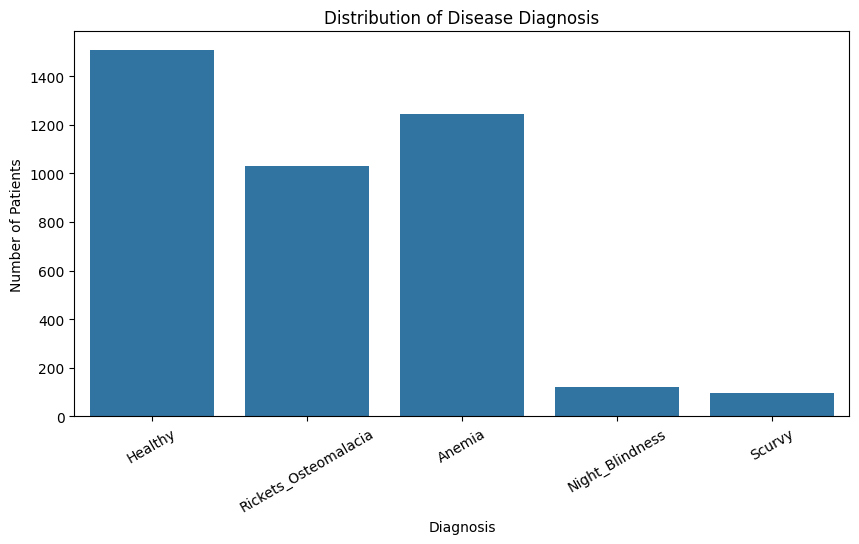

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="disease_diagnosis"
)

plt.xticks(rotation=30)
plt.title("Distribution of Disease Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
print(df["has_multiple_deficiencies"].value_counts())

has_multiple_deficiencies
0    2611
1    1389
Name: count, dtype: int64


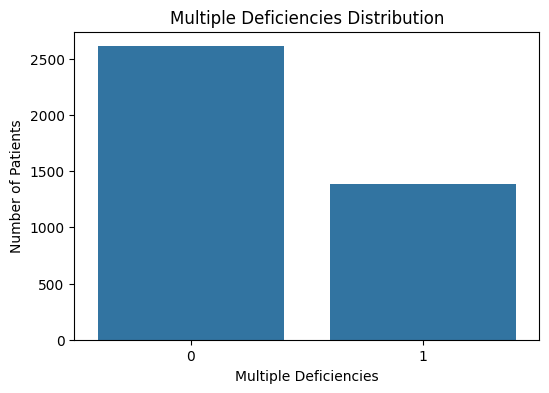

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="has_multiple_deficiencies"
)

plt.title("Multiple Deficiencies Distribution")
plt.xlabel("Multiple Deficiencies")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
df = df.drop(columns=["symptoms_list"])

In [ ]:
print("symptoms_list" in df.columns)

False


In [ ]:
df["alcohol_consumption"] = df["alcohol_consumption"].fillna("Unknown")

In [ ]:
print(df["alcohol_consumption"].isnull().sum())

0


In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [ ]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns.tolist())

['gender', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'disease_diagnosis']


In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=False
)

In [ ]:
df_encoded.head()

,age,bmi,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,...,income_level_Low,income_level_Middle,latitude_region_High,latitude_region_Low,latitude_region_Mid,disease_diagnosis_Anemia,disease_diagnosis_Healthy,disease_diagnosis_Night_Blindness,disease_diagnosis_Rickets_Osteomalacia,disease_diagnosis_Scurvy
0,79,24.8,119.1,147.3,152.88,97.5,102.5,188.9,108.3,97.4,...,False,False,False,False,True,False,True,False,False,False
1,77,39.9,85.7,57.5,32.76,82.7,62.6,51.0,42.6,102.5,...,True,False,False,True,False,False,False,False,True,False
2,24,26.4,48.3,152.1,94.99,169.3,136.2,116.6,136.3,86.4,...,False,False,True,False,False,False,True,False,False,False
3,69,23.1,75.8,51.0,51.48,85.7,31.8,66.5,76.5,60.8,...,True,False,False,True,False,True,False,False,False,False
4,63,29.6,93.3,111.5,62.90,155.6,72.6,124.9,69.4,71.9,...,False,False,False,True,False,False,True,False,False,False


In [ ]:
print(df_encoded.dtypes.value_counts())

bool       30
float64    13
int64      11
Name: count, dtype: int64


In [ ]:
bool_columns = df_encoded.select_dtypes(include="bool").columns

df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

In [ ]:
print("Final shape:", df_encoded.shape)

print("\nMissing values:")
print(df_encoded.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_encoded.duplicated().sum())

Final shape: (4000, 54)

Missing values:
0

Duplicate rows:
0


In [ ]:
y = df["disease_diagnosis"]

X = df.drop(
    columns=["disease_diagnosis", "has_multiple_deficiencies"]
)

In [ ]:
X = pd.get_dummies(X, drop_first=False)

X = X.astype(int)

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4000, 48)
y shape: (4000,)


In [ ]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [ ]:
target_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print(target_mapping)

{'Anemia': np.int64(0), 'Healthy': np.int64(1), 'Night_Blindness': np.int64(2), 'Rickets_Osteomalacia': np.int64(3), 'Scurvy': np.int64(4)}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3200
Testing samples: 800


In [ ]:
preprocessed_df = X.copy()

preprocessed_df["disease_diagnosis"] = y_encoded

In [ ]:
preprocessed_df.to_csv(
    "vitamin_deficiency_preprocessed.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("vitamin_deficiency_preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>